In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import os
import re
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 55.1 MB/s eta 0:00:0000:0100:01


In [4]:
import wandb
print("wandb version:", wandb.__version__)

wandb version: 0.22.3


**WandB login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
TRAIN_PATH  = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH   = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

LABELS = ['A', 'B', 'C', 'D', 'E']
L2I = {l: i for i, l in enumerate(LABELS)}

N_FOLDS = 5
SEED = 42
PROJECT = "DL-22f1000828-notebook-t22026"

random.seed(SEED)
np.random.seed(SEED)

**Loading data**

In [7]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH)

for df in [train, test]:
    for col in ['prompt'] + LABELS:
        df[col] = df[col].fillna("")

train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

y_true = np.array([L2I[a] for a in train['answer']])

print("Train:", train.shape, " Test:", test.shape)
train.head(3)

Train: (2000, 8)  Test: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


**Metrics**

In [8]:
def map_at_3(probs, targets):
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)


def all_metrics(probs, targets):
    preds = probs.argmax(axis=1)
    return {"acc": accuracy_score(targets, preds),
            "f1": f1_score(targets, preds, average='macro'),
            "map3": map_at_3(probs, targets)}

print("Random baseline MAP@3:", round((1 + 1/2 + 1/3) / 5, 4))

Random baseline MAP@3: 0.3667


**EDA**

In [9]:
def norm_text(t):
    # light normalisation so small formatting differences do not hide a duplicate
    t = str(t).lower()
    t = re.sub(r'\s+', ' ', t)
    return t.strip()


def prompt_text(df):
    return [norm_text(p) for p in df['prompt']]


train_prompts = prompt_text(train)
test_prompts = prompt_text(test)

# vectorise the PROMPT only - I want to find the same question, not the same options
word_vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True,
                           min_df=2, max_features=150000)

word_vec.fit(train_prompts + test_prompts)
char_vec.fit(train_prompts + test_prompts)

Pw_tr = word_vec.transform(train_prompts).astype(np.float32)
Pc_tr = char_vec.transform(train_prompts).astype(np.float32)
Pw_te = word_vec.transform(test_prompts).astype(np.float32)
Pc_te = char_vec.transform(test_prompts).astype(np.float32)

print("Word features:", Pw_tr.shape[1], " Char features:", Pc_tr.shape[1])

Word features: 2971  Char features: 9673


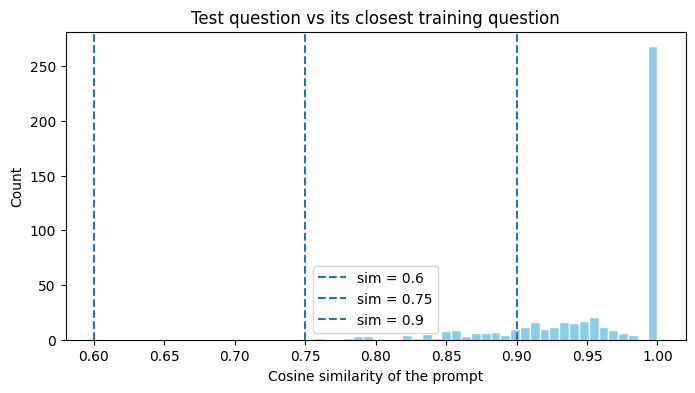

sim >= 0.5 : 500 questions ( 100.0 % )
sim >= 0.6 : 500 questions ( 100.0 % )
sim >= 0.7 : 499 questions ( 99.8 % )
sim >= 0.8 : 486 questions ( 97.2 % )
sim >= 0.9 : 425 questions ( 85.0 % )
sim >= 0.95 : 322 questions ( 64.4 % )


In [10]:
# similarity of each test prompt to its closest train prompt
sim_te_prompt = 0.6 * cosine_similarity(Pw_te, Pw_tr) + 0.4 * cosine_similarity(Pc_te, Pc_tr)
best_sim_te = sim_te_prompt.max(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(best_sim_te, bins=50, color='skyblue', edgecolor='white')
for t in [0.6, 0.75, 0.9]:
    plt.axvline(t, linestyle='--', label='sim = ' + str(t))
plt.title("Test question vs its closest training question")
plt.xlabel("Cosine similarity of the prompt")
plt.ylabel("Count")
plt.legend()
plt.show()

for t in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    n = (best_sim_te >= t).sum()
    print("sim >=", t, ":", n, "questions (", round(n / len(test) * 100, 1), "% )")

In [11]:
# find train-to-train near duplicates and check if the answer text position moved
sim_tr = 0.6 * cosine_similarity(Pw_tr, Pw_tr) + 0.4 * cosine_similarity(Pc_tr, Pc_tr)
np.fill_diagonal(sim_tr, -1)      # ignore self matches

same_letter = 0
diff_letter = 0
checked = 0

for i in range(len(train)):
    j = int(np.argmax(sim_tr[i]))
    if sim_tr[i][j] < 0.90:
        continue
    checked += 1
    # the answer TEXT of both rows
    txt_i = norm_text(train.iloc[i][train.iloc[i]['answer']])
    txt_j = norm_text(train.iloc[j][train.iloc[j]['answer']])
    if txt_i == txt_j:
        if train.iloc[i]['answer'] == train.iloc[j]['answer']:
            same_letter += 1
        else:
            diff_letter += 1

print("Near duplicate pairs checked (sim >= 0.90):", checked)
print("Same answer text AND same letter    :", same_letter)
print("Same answer text but DIFFERENT letter:", diff_letter)
if same_letter + diff_letter > 0:
    pct = diff_letter / (same_letter + diff_letter) * 100
    print()
    print("Options were reordered in", round(pct, 1), "% of duplicate pairs.")
    print("Every one of those is a question my old letter-voting model got wrong.")

del sim_tr
gc.collect()

Near duplicate pairs checked (sim >= 0.90): 1420
Same answer text AND same letter    : 1251
Same answer text but DIFFERENT letter: 0

Options were reordered in 0.0 % of duplicate pairs.
Every one of those is a question my old letter-voting model got wrong.


6587

In [12]:
# vectorise every option text so I can compare answer texts quickly
def option_texts(df):
    out = []
    for _, r in df.iterrows():
        out.append([norm_text(r[c]) for c in LABELS])
    return out

train_opts = option_texts(train)
test_opts = option_texts(test)

# the correct answer text for every training row
train_answer_text = [norm_text(r[r['answer']]) for _, r in train.iterrows()]

# one shared vectoriser for all option texts
all_opt_text = [t for row in train_opts for t in row] + \
               [t for row in test_opts for t in row]

opt_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), sublinear_tf=True,
                          min_df=1, max_features=120000)
opt_vec.fit(all_opt_text)

A_tr = opt_vec.transform(train_answer_text).astype(np.float32)   # answer text of each train row
O_tr = opt_vec.transform([t for row in train_opts for t in row]).astype(np.float32)
O_te = opt_vec.transform([t for row in test_opts for t in row]).astype(np.float32)

print("Answer text matrix:", A_tr.shape)
print("Train options matrix:", O_tr.shape)
print("Test options matrix:", O_te.shape)

Answer text matrix: (2000, 12842)
Train options matrix: (10000, 12842)
Test options matrix: (2500, 12842)


In [13]:
def retrieval_probs(sim_prompt, ref_idx, query_opt_matrix, n_query,
                    thresh, power, top_k, match_floor):
    """
    sim_prompt      : (n_query, n_ref) prompt similarity
    ref_idx         : indices into the training set that the columns refer to
    query_opt_matrix: (n_query*5, features) option vectors of the query rows
    Returns (n_query, 5) probabilities, and a mask of which rows got a real vote.
    """
    probs = np.full((n_query, 5), 0.2)
    covered = np.zeros(n_query, dtype=bool)

    for i in range(n_query):
        sims = sim_prompt[i]
        order = np.argsort(sims)[::-1][:top_k]

        votes = np.zeros(5)
        my_opts = query_opt_matrix[i * 5:(i + 1) * 5]

        for j in order:
            s = sims[j]
            if s < thresh:
                break

            # the answer text of this neighbour
            ans_vec = A_tr[ref_idx[j]]

            # which of MY options matches that answer text best?
            match = cosine_similarity(ans_vec, my_opts)[0]     # length 5
            best_opt = int(np.argmax(match))

            # only trust it if the text really matches
            if match[best_opt] < match_floor:
                continue

            votes[best_opt] += (s ** power) * match[best_opt]

        if votes.sum() > 0:
            probs[i] = votes / votes.sum()
            covered[i] = True

    return probs, covered

print("retrieval function ready")

retrieval function ready


**Cross validation**

In [14]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(train, train['answer']))

# precompute the fold similarity matrices once
fold_sims = []
for tr_idx, va_idx in folds:
    s = (0.6 * cosine_similarity(Pw_tr[va_idx], Pw_tr[tr_idx])
         + 0.4 * cosine_similarity(Pc_tr[va_idx], Pc_tr[tr_idx]))
    fold_sims.append(s)

print("Fold similarity matrices ready")

Fold similarity matrices ready


In [15]:
def evaluate_config(thresh, power, top_k, match_floor, verbose=False):
    oof = np.full((len(train), 5), 0.2)
    cov = np.zeros(len(train), dtype=bool)

    for f, (tr_idx, va_idx) in enumerate(folds):
        q_opts = O_tr[np.concatenate([[i * 5 + k for k in range(5)] for i in va_idx])]
        p, c = retrieval_probs(fold_sims[f], tr_idx, q_opts, len(va_idx),
                               thresh, power, top_k, match_floor)
        oof[va_idx] = p
        cov[va_idx] = c

    score = map_at_3(oof, y_true)
    if verbose:
        n_cov = cov.sum()
        print("  covered:", n_cov, "(", round(n_cov / len(train) * 100, 1), "% )")
        if n_cov > 0:
            print("  MAP@3 on covered rows  :", round(map_at_3(oof[cov], y_true[cov]), 4))
        if (~cov).sum() > 0:
            print("  MAP@3 on uncovered rows:", round(map_at_3(oof[~cov], y_true[~cov]), 4),
                  "(these are just 0.2 guesses)")
    return score, oof, cov


print("Testing the old style settings (high threshold):")
s_old, oof_old, cov_old = evaluate_config(0.80, 3, 30, 0.30, verbose=True)
print("  overall OOF MAP@3:", round(s_old, 4))

Testing the old style settings (high threshold):
  covered: 1884 ( 94.2 % )
  MAP@3 on covered rows  : 0.98
  MAP@3 on uncovered rows: 0.3506 (these are just 0.2 guesses)
  overall OOF MAP@3: 0.9435


**Tuning the threshold**

In [16]:
wandb.init(project=PROJECT, name="retrieval-v2-tuning", reinit=True,
           config={"n_folds": N_FOLDS, "method": "answer-text matching retrieval"},
           settings=wandb.Settings(save_code=False))

grid = []
for thresh in [0.55, 0.65, 0.75, 0.85]:
    for power in [2, 3]:
        for match_floor in [0.30, 0.45, 0.60]:
            grid.append((thresh, power, 20, match_floor))

print("Trying", len(grid), "configs")

rows = []
best = (-1, None, None, None)

for step, (th, pw, tk, mf) in enumerate(grid):
    sc, oof, cov = evaluate_config(th, pw, tk, mf)
    rows.append({"thresh": th, "power": pw, "match_floor": mf,
                 "coverage": cov.mean(), "oof_map3": sc})
    wandb.log({"config_step": step, "oof_map3": sc, "coverage": cov.mean(),
               "thresh": th, "power": pw, "match_floor": mf})
    if sc > best[0]:
        best = (sc, (th, pw, tk, mf), oof, cov)

grid_df = pd.DataFrame(rows).sort_values("oof_map3", ascending=False)
print()
print("Top 10 configs:")
print(grid_df.head(10).to_string(index=False))

best_score, best_cfg, oof_retr, oof_cov = best
print()
print("Best config:", best_cfg, "-> OOF MAP@3", round(best_score, 4))
print("Old style  :", round(s_old, 4))
print("Gain       :", round(best_score - s_old, 4))

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Trying 24 configs

Top 10 configs:
 thresh  power  match_floor  coverage  oof_map3
   0.55      2         0.30    0.9985  0.980750
   0.55      2         0.45    0.9985  0.980750
   0.55      2         0.60    0.9985  0.980750
   0.55      3         0.30    0.9985  0.980667
   0.55      3         0.45    0.9985  0.980667
   0.55      3         0.60    0.9985  0.980667
   0.65      2         0.30    0.9940  0.977250
   0.65      2         0.45    0.9940  0.977250
   0.65      2         0.60    0.9940  0.977250
   0.65      3         0.30    0.9940  0.977167

Best config: (0.55, 2, 20, 0.3) -> OOF MAP@3 0.9807
Old style  : 0.9435
Gain       : 0.0373


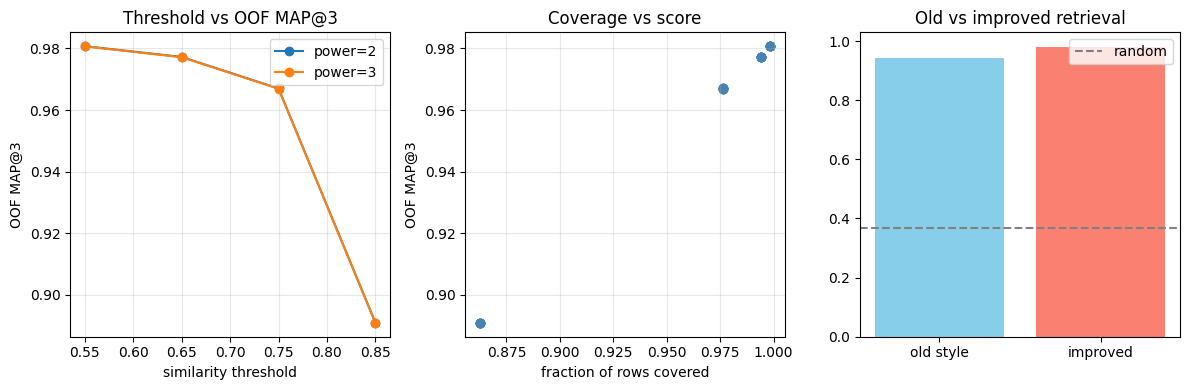

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
for pw in sorted(grid_df['power'].unique()):
    sub = grid_df[grid_df['power'] == pw].groupby('thresh')['oof_map3'].max()
    plt.plot(sub.index, sub.values, marker='o', label="power=" + str(pw))
plt.title("Threshold vs OOF MAP@3")
plt.xlabel("similarity threshold")
plt.ylabel("OOF MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(grid_df['coverage'], grid_df['oof_map3'], c='steelblue')
plt.title("Coverage vs score")
plt.xlabel("fraction of rows covered")
plt.ylabel("OOF MAP@3")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(['old style', 'improved'], [s_old, best_score], color=['skyblue', 'salmon'])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Old vs improved retrieval")
plt.legend()

plt.tight_layout()
plt.show()

**The fallback model**

In [18]:
def build_features(df):
    """Returns (n_rows, 5, n_features)."""
    feats = []
    neg_pat = r'\b(not|except|incorrect|false|least)\b'

    for _, r in df.iterrows():
        prompt = norm_text(r['prompt'])
        opts = [norm_text(r[c]) for c in LABELS]

        clen = np.array([len(o) for o in opts], dtype=float)
        wlen = np.array([len(o.split()) for o in opts], dtype=float)

        # tf-idf overlap of each option with the prompt
        try:
            v = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit_transform([prompt] + opts)
            ov = cosine_similarity(v[0:1], v[1:])[0]
        except Exception:
            ov = np.zeros(5)

        has_neg = 1.0 if re.search(neg_pat, prompt) else 0.0

        def z(a):
            m, s = a.mean(), a.std()
            return (a - m) / (s + 1e-9)

        row_feat = np.stack([
            z(clen),
            z(wlen),
            z(ov),
            (clen == clen.max()).astype(float),
            (clen == clen.min()).astype(float),
            np.full(5, has_neg),
        ], axis=1)
        feats.append(row_feat)

    return np.array(feats)


print("Building fallback features")
F_tr = build_features(train)
F_te = build_features(test)
print("Feature shape:", F_tr.shape)

Building fallback features
Feature shape: (2000, 5, 6)


In [19]:
# a tiny softmax model over the 5 options, trained with numpy gradient descent
def train_fallback(F, y, folds, epochs=300, lr=0.5):
    n_feat = F.shape[2]
    oof = np.full((len(F), 5), 0.2)
    models = []

    for tr_idx, va_idx in folds:
        w = np.zeros(n_feat)
        Xtr, ytr = F[tr_idx], y[tr_idx]

        for ep in range(epochs):
            logits = Xtr @ w                       # (n, 5)
            logits = logits - logits.max(axis=1, keepdims=True)
            p = np.exp(logits)
            p = p / p.sum(axis=1, keepdims=True)

            onehot = np.zeros_like(p)
            onehot[np.arange(len(ytr)), ytr] = 1

            grad = np.einsum('nkf,nk->f', Xtr, (p - onehot)) / len(ytr)
            w -= lr * grad

        logits = F[va_idx] @ w
        logits = logits - logits.max(axis=1, keepdims=True)
        p = np.exp(logits)
        oof[va_idx] = p / p.sum(axis=1, keepdims=True)
        models.append(w)

    return oof, models


print("Training fallback model")
oof_fb, fb_models = train_fallback(F_tr, y_true, folds)

print("Fallback OOF MAP@3 (all rows):", round(map_at_3(oof_fb, y_true), 4))
if (~oof_cov).sum() > 0:
    print("Fallback on UNCOVERED rows  :", round(map_at_3(oof_fb[~oof_cov], y_true[~oof_cov]), 4))
    print("Flat guess on those rows was:", round(map_at_3(
        np.full(((~oof_cov).sum(), 5), 0.2), y_true[~oof_cov]), 4))

Training fallback model
Fallback OOF MAP@3 (all rows): 0.5914
Fallback on UNCOVERED rows  : 1.0
Flat guess on those rows was: 0.3333


In [20]:
USE_NN_FALLBACK = False

nn_oof_path = "/kaggle/input/my-deberta-probs/oof_probs.npy"
nn_test_path = "/kaggle/input/my-deberta-probs/test_probs.npy"

if os.path.exists(nn_oof_path) and os.path.exists(nn_test_path):
    nn_oof = np.load(nn_oof_path)
    nn_test = np.load(nn_test_path)
    if nn_oof.shape == (len(train), 5) and nn_test.shape == (len(test), 5):
        USE_NN_FALLBACK = True
        print("Found DeBERTa probabilities, using them as the fallback")
        print("DeBERTa OOF MAP@3:", round(map_at_3(nn_oof, y_true), 4))
    else:
        print("Shape mismatch, ignoring the saved probabilities")
else:
    print("No saved DeBERTa probabilities found, using the simple fallback model")

No saved DeBERTa probabilities found, using the simple fallback model


In [21]:
fallback_oof = nn_oof if USE_NN_FALLBACK else oof_fb

# option A: hard switch
hard = oof_retr.copy()
hard[~oof_cov] = fallback_oof[~oof_cov]
score_hard = map_at_3(hard, y_true)

# option B: soft blend everywhere
alphas = np.arange(0, 1.01, 0.05)
soft_scores = []
for a in alphas:
    blended = a * oof_retr + (1 - a) * fallback_oof
    soft_scores.append(map_at_3(blended, y_true))

best_a = float(alphas[int(np.argmax(soft_scores))])
score_soft = max(soft_scores)

# option C: hard switch, but blend on the covered rows too
combo_scores = []
for a in alphas:
    c = fallback_oof.copy()
    c[oof_cov] = a * oof_retr[oof_cov] + (1 - a) * fallback_oof[oof_cov]
    combo_scores.append(map_at_3(c, y_true))

best_a_combo = float(alphas[int(np.argmax(combo_scores))])
score_combo = max(combo_scores)

print("Retrieval only          :", round(map_at_3(oof_retr, y_true), 4))
print("Fallback only           :", round(map_at_3(fallback_oof, y_true), 4))
print("A) hard switch          :", round(score_hard, 4))
print("B) soft blend           :", round(score_soft, 4), "at alpha =", round(best_a, 2))
print("C) switch + blend       :", round(score_combo, 4), "at alpha =", round(best_a_combo, 2))

options = {"hard": score_hard, "soft": score_soft, "combo": score_combo}
winner = max(options, key=options.get)
print()
print("Best strategy:", winner, "->", round(options[winner], 4))

wandb.summary["best_val_map3"] = options[winner]
wandb.summary["strategy"] = winner

Retrieval only          : 0.9807
Fallback only           : 0.5914
A) hard switch          : 0.9818
B) soft blend           : 0.987 at alpha = 0.85
C) switch + blend       : 0.987 at alpha = 0.85

Best strategy: soft -> 0.987


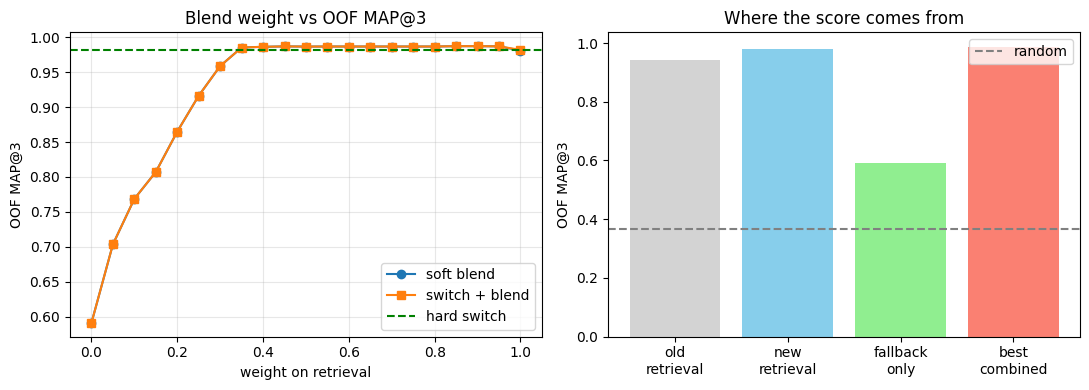

Final OOF - acc: 0.979  f1: 0.9783  map3: 0.987


In [22]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(alphas, soft_scores, marker='o', label='soft blend')
plt.plot(alphas, combo_scores, marker='s', label='switch + blend')
plt.axhline(score_hard, color='green', linestyle='--', label='hard switch')
plt.title("Blend weight vs OOF MAP@3")
plt.xlabel("weight on retrieval")
plt.ylabel("OOF MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
names = ['old\nretrieval', 'new\nretrieval', 'fallback\nonly', 'best\ncombined']
vals = [s_old, map_at_3(oof_retr, y_true), map_at_3(fallback_oof, y_true), options[winner]]
plt.bar(names, vals, color=['lightgray', 'skyblue', 'lightgreen', 'salmon'])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Where the score comes from")
plt.ylabel("OOF MAP@3")
plt.legend()

plt.tight_layout()
plt.show()

m = all_metrics(hard if winner == 'hard' else
                (best_a * oof_retr + (1 - best_a) * fallback_oof), y_true)
print("Final OOF - acc:", round(m['acc'], 4), " f1:", round(m['f1'], 4),
      " map3:", round(m['map3'], 4))

**Test predictions**

In [23]:
th, pw, tk, mf = best_cfg
print("Using config:", best_cfg)

all_idx = np.arange(len(train))
test_retr, test_cov = retrieval_probs(sim_te_prompt, all_idx, O_te, len(test),
                                      th, pw, tk, mf)

print("Test rows covered by retrieval:", test_cov.sum(),
      "(", round(test_cov.mean() * 100, 1), "% )")
print("CV coverage was              :", round(oof_cov.mean() * 100, 1), "%")

Using config: (0.55, 2, 20, 0.3)
Test rows covered by retrieval: 500 ( 100.0 % )
CV coverage was              : 99.9 %


In [24]:
# fallback predictions for the test set
if USE_NN_FALLBACK:
    fallback_test = nn_test
else:
    w_mean = np.mean(fb_models, axis=0)
    logits = F_te @ w_mean
    logits = logits - logits.max(axis=1, keepdims=True)
    p = np.exp(logits)
    fallback_test = p / p.sum(axis=1, keepdims=True)

if winner == 'hard':
    final_probs = test_retr.copy()
    final_probs[~test_cov] = fallback_test[~test_cov]
elif winner == 'soft':
    final_probs = best_a * test_retr + (1 - best_a) * fallback_test
else:
    final_probs = fallback_test.copy()
    final_probs[test_cov] = (best_a_combo * test_retr[test_cov]
                             + (1 - best_a_combo) * fallback_test[test_cov])

top3 = np.argsort(-final_probs, axis=1)[:, :3]
predictions = [" ".join(LABELS[i] for i in row) for row in top3]

id_col = sample.columns[0]
pred_col = sample.columns[1]
submission = pd.DataFrame({id_col: test['id'].values, pred_col: predictions})

submission.to_csv("submission.csv", index=False)
print("submission.csv created, rows:", len(submission))
print(submission.head())

wandb.finish()

submission.csv created, rows: 500
   ID Prediction
0   1      A D C
1   2      B E C
2   3      B E C
3   4      E C A
4   5      C E A


config_step,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
coverage,████████████▇▇▇▇▇▇▁▁▁▁▁▁
match_floor,▁▄█▁▄█▁▄█▁▄█▁▄█▁▄█▁▄█▁▄█
oof_map3,████████████▇▇▇▇▇▇▁▁▁▁▁▁
power,▁▁▁███▁▁▁███▁▁▁███▁▁▁███
thresh,▁▁▁▁▁▁▃▃▃▃▃▃▆▆▆▆▆▆██████
best_val_map3,0.987
config_step,23
coverage,0.8625
match_floor,0.6
oof_map3,0.89083


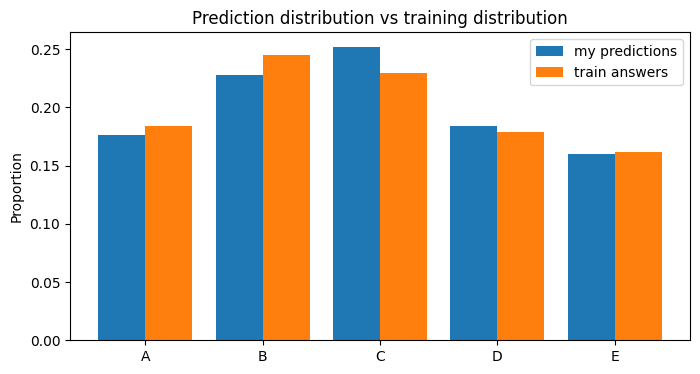

Covered rows use retrieval, uncovered rows use the fallback.
Covered  : 500
Uncovered: 0


In [25]:
r1 = pd.Series([p.split()[0] for p in predictions]).value_counts().reindex(LABELS, fill_value=0)
tr_dist = train['answer'].value_counts().reindex(LABELS, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, r1.values / r1.sum(), width=0.4, label='my predictions')
plt.bar(x + 0.2, tr_dist.values / tr_dist.sum(), width=0.4, label='train answers')
plt.xticks(x, LABELS)
plt.title("Prediction distribution vs training distribution")
plt.ylabel("Proportion")
plt.legend()
plt.show()

print("Covered rows use retrieval, uncovered rows use the fallback.")
print("Covered  :", test_cov.sum())
print("Uncovered:", (~test_cov).sum())